<div style="background-color:#7BAFD4;border-radius:18px;padding:22px 26px;margin-bottom:18px;">
<div style="font-family:Impact,'Arial Black',Arial,sans-serif;font-size:42px;font-weight:900;letter-spacing:2px;color:white;">GEOG 592</div>
<div style="font-family:Arial,sans-serif;font-size:22px;font-weight:700;color:#13294B;margin-top:8px;">GIS Programming</div>
<div style="font-family:Arial,sans-serif;font-size:16px;color:#13294B;margin-top:6px;">NumPy — Raster Data Example</div>
</div>

# Raster Data with NumPy

A raster can be represented as a 2-dimensional NumPy array. 

We will begin with very small rasters so we can see every value and understand exactly what NumPy is doing, and then move into working with a real world raster. 


## Create an elevation raster

Imagine that these values represent elevation in meters. The raster has 5 rows and 5 columns.


In [1]:
import numpy as np

elevation = np.array([
    [120, 125, 130, 135, 140],
    [118, 123, 128, 140, 150],
    [115, 120, 135, 155, 165],
    [110, 118, 140, 160, 175],
    [105, 115, 130, 150, 170]
])

elevation

array([[120, 125, 130, 135, 140],
       [118, 123, 128, 140, 150],
       [115, 120, 135, 155, 165],
       [110, 118, 140, 160, 175],
       [105, 115, 130, 150, 170]])

## Inspect the raster

`.shape` reports the number of rows and columns.


In [2]:
elevation.shape

(5, 5)

The result `(5, 5)` means 5 rows × 5 columns. We can also count all cells:

In [3]:
elevation.size

25

## Access raster cells

NumPy uses:

```python
array[row, column]
```

Python begins counting at 0. Retrieve the value at row index 2, column index 3:


In [4]:
elevation[2, 3]

np.int64(155)

Retrieve an entire row:

In [5]:
elevation[2, :]

array([115, 120, 135, 155, 165])

Retrieve an entire column:

In [6]:
elevation[:, 3]

array([135, 140, 155, 160, 150])

## Calculate raster statistics

In [7]:
print("Minimum elevation:", elevation.min())
print("Maximum elevation:", elevation.max())
print("Mean elevation:", elevation.mean())
print("Median elevation:", np.median(elevation))

Minimum elevation: 105
Maximum elevation: 175
Mean elevation: 134.88
Median elevation: 130.0


## Visualize the raster

Matplotlib's `imshow()` displays a 2-dimensional array as an image.


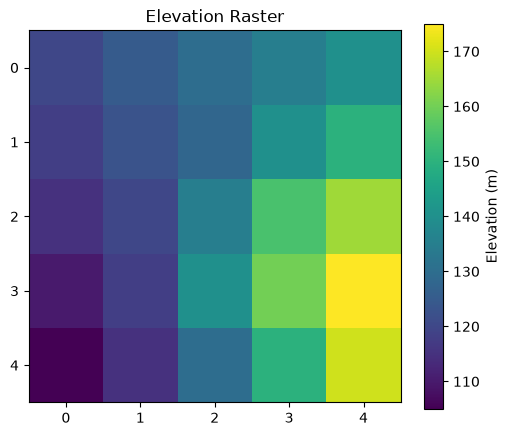

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(elevation)
fig.colorbar(image, ax=ax, label="Elevation (m)")

ax.set_title("Elevation Raster")
plt.show()

## Select cells with a condition

Identify cells with elevations greater than or equal to 150 meters. A NumPy comparison produces a Boolean raster containing `True` and `False`.


In [9]:
high_elevation = elevation >= 150

high_elevation

array([[False, False, False, False, False],
       [False, False, False, False,  True],
       [False, False, False,  True,  True],
       [False, False, False,  True,  True],
       [False, False, False,  True,  True]])

Use the Boolean raster as a mask to retrieve the original values:

In [10]:
elevation[high_elevation]

array([150, 155, 165, 160, 175, 150, 170])

We can count the cells satisfying the condition. In NumPy, `True` behaves like 1 and `False` like 0.

In [11]:
high_elevation.sum()

np.int64(7)

## Reclassify the raster

Create a new raster using `np.where()`.


In [12]:
elevation_class = np.where(
    elevation >= 150,
    1,
    0
)

elevation_class

array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1],
       [0, 0, 0, 1, 1],
       [0, 0, 0, 1, 1],
       [0, 0, 0, 1, 1]])

The new raster has the same dimensions as the original:

In [13]:
print("Original raster:", elevation.shape)
print("Reclassified raster:", elevation_class.shape)

Original raster: (5, 5)
Reclassified raster: (5, 5)


## Visualize the reclassified raster

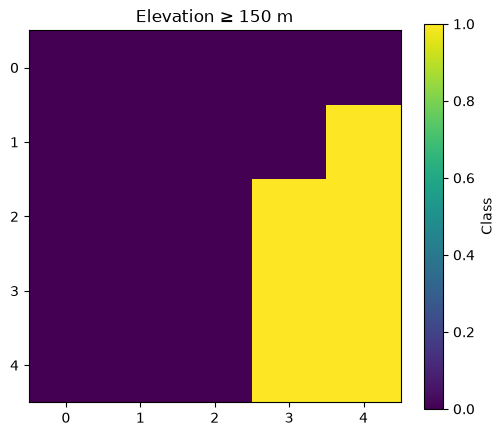

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(elevation_class)
fig.colorbar(image, ax=ax, label="Class")

ax.set_title("Elevation ≥ 150 m")
plt.show()

## Work with two rasters

Suppose a second raster represents temperature in °C. Each cell corresponds to the same location as the cell in the same row and column of the elevation raster.


In [15]:
temperature = np.array([
    [24, 24, 23, 22, 21],
    [25, 24, 23, 21, 20],
    [26, 25, 22, 20, 19],
    [27, 26, 22, 19, 18],
    [28, 27, 24, 21, 19]
])

temperature

array([[24, 24, 23, 22, 21],
       [25, 24, 23, 21, 20],
       [26, 25, 22, 20, 19],
       [27, 26, 22, 19, 18],
       [28, 27, 24, 21, 19]])

For this simplified example, both rasters have the same shape:

In [16]:
print("Elevation:", elevation.shape)
print("Temperature:", temperature.shape)

Elevation: (5, 5)
Temperature: (5, 5)


## A simple suitability analysis

Imagine a hypothetical species prefers locations where:

- elevation is at least 140 meters, AND
- temperature is 22°C or lower.

We can evaluate both conditions across all cells at once.


In [17]:
suitable = (
    (elevation >= 140) &
    (temperature <= 22)
)

suitable

array([[False, False, False, False,  True],
       [False, False, False,  True,  True],
       [False, False, False,  True,  True],
       [False, False,  True,  True,  True],
       [False, False, False,  True,  True]])

Create a new raster where `1` means suitable and `0` means not suitable:

In [18]:
suitability = np.where(suitable, 1, 0)

suitability

array([[0, 0, 0, 0, 1],
       [0, 0, 0, 1, 1],
       [0, 0, 0, 1, 1],
       [0, 0, 1, 1, 1],
       [0, 0, 0, 1, 1]])

## Visualize the suitability result

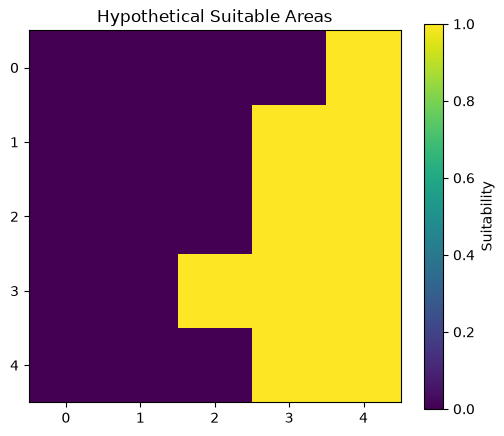

In [19]:
fig, ax = plt.subplots(figsize=(6, 5))

image = ax.imshow(suitability)
fig.colorbar(image, ax=ax, label="Suitability")

ax.set_title("Hypothetical Suitable Areas")
plt.show()

## Working with real data

In [20]:
from PIL import Image ## we need PIL to open tif files. pip install if needed. 
import numpy as np

In [21]:
## open raster
DEM_file = "./data/puerto_rico_vieques_culebra_mona_dem_30m.tif"
raster = np.array(Image.open(DEM_file))
raster[np.isnan(raster)] = 0

In [22]:
raster.shape

(3831, 10635)

In [23]:
print(raster.min())
print(raster.max()) ## Pico Duarte 3,101 m
print(raster.mean())

## water will rise to approx. 70m when all glaciers are melted.

classified = np.where(raster > 70, 1, 0)

-8.838785
1328.76
57.695618


In [24]:
# How much land will be under water?
# number of pixel under zero before and after
classified.shape
## Print KM2s that will be under water using a very simple analysis
print("km2 of Puerto Rico =", ((np.count_nonzero(raster > 0))*900/1000000))
print("km2 of Puerto Rico under water =",(np.count_nonzero((raster > 0) & (raster <= 70)))*900/1000000)

km2 of Puerto Rico = 8917.7634
km2 of Puerto Rico under water = 2667.4236


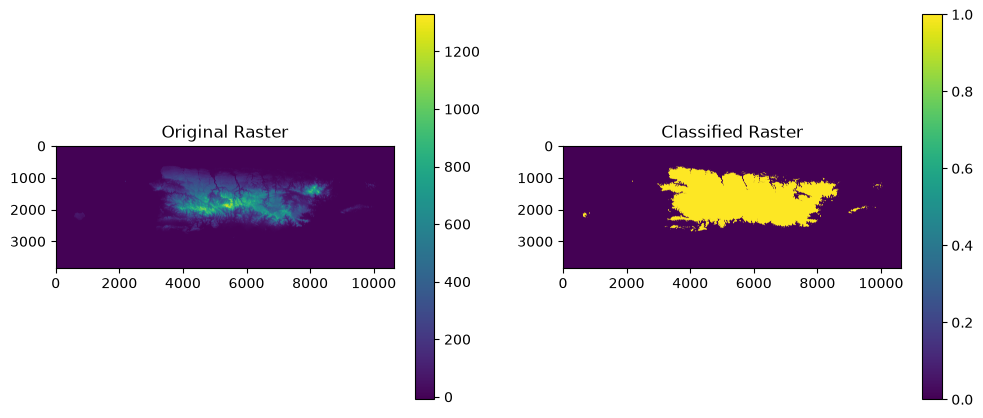

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Original raster
image1 = ax[0].imshow(raster)
ax[0].set_title("Original Raster")
fig.colorbar(image1, ax=ax[0])

# Classified raster
image2 = ax[1].imshow(classified)
ax[1].set_title("Classified Raster")
fig.colorbar(image2, ax=ax[1])

plt.show()

In [26]:
## animation made using AI coding help. 

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

elevation = raster

fig, ax = plt.subplots(figsize=(7, 6))

terrain = ax.imshow(elevation, cmap="terrain")

water = np.ma.masked_where(
    elevation > 0,
    elevation
)

water_image = ax.imshow(
    water,
    cmap="Blues",
    vmin=0,
    vmax=80
)

ax.set_axis_off()

def update(water_level):

    flooded = np.ma.masked_where(
        elevation > water_level,
        elevation
    )

    water_image.set_data(flooded)

    ax.set_title(f"Water Level: {water_level} m")

    return water_image,

animation = FuncAnimation(
    fig,
    update,
    frames=range(0, 81, 10),
    interval=150
)

plt.close()

HTML(animation.to_jshtml())